## 0. Load the libraries

In [37]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import ast

# 1. Load the saved results



In [39]:
eval_df = pd.read_csv('../results/results_with_metrics.csv')

distributed_stations = pd.read_csv('../data/distributed_stations.csv')

# 2. Evaluation

Evaluation metrics:
* **Root Mean Squared Error (RMSE)** measures the square root of the average squared difference between predicted and observed values.
* **Mean Absolute Error (MAE)** measures the average of the absolute differences between predicted and observed values.
* **Bias** measures the average difference between predicted and observed values, indicating if predictions are systematically over- or under-estimated.


In [40]:
eval_df[['Target', 'RMSE', 'MAE', 'Bias']]

,Target,RMSE,MAE,Bias
0,temperature_max_target_21,5.315998,4.184329,0.313466
1,temperature_max_target_22,5.318017,4.170542,0.417120
2,temperature_max_target_23,5.329372,4.190544,0.532692
3,temperature_max_target_24,5.282798,4.140108,0.332022
4,temperature_max_target_25,5.327293,4.229740,0.302218
5,temperature_max_target_26,5.324626,4.227146,0.251072
6,temperature_max_target_27,5.438053,4.243026,0.276438
7,temperature_max_target_28,5.512362,4.266533,0.114409
8,temperature_max_target_29,5.496466,4.251176,0.104635
9,temperature_max_target_30,5.629544,4.387467,0.059215


C:\Users\Мария\AppData\Local\Temp\ipykernel_17836\1538350039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_results, x='Target', y='RMSE', palette='viridis')


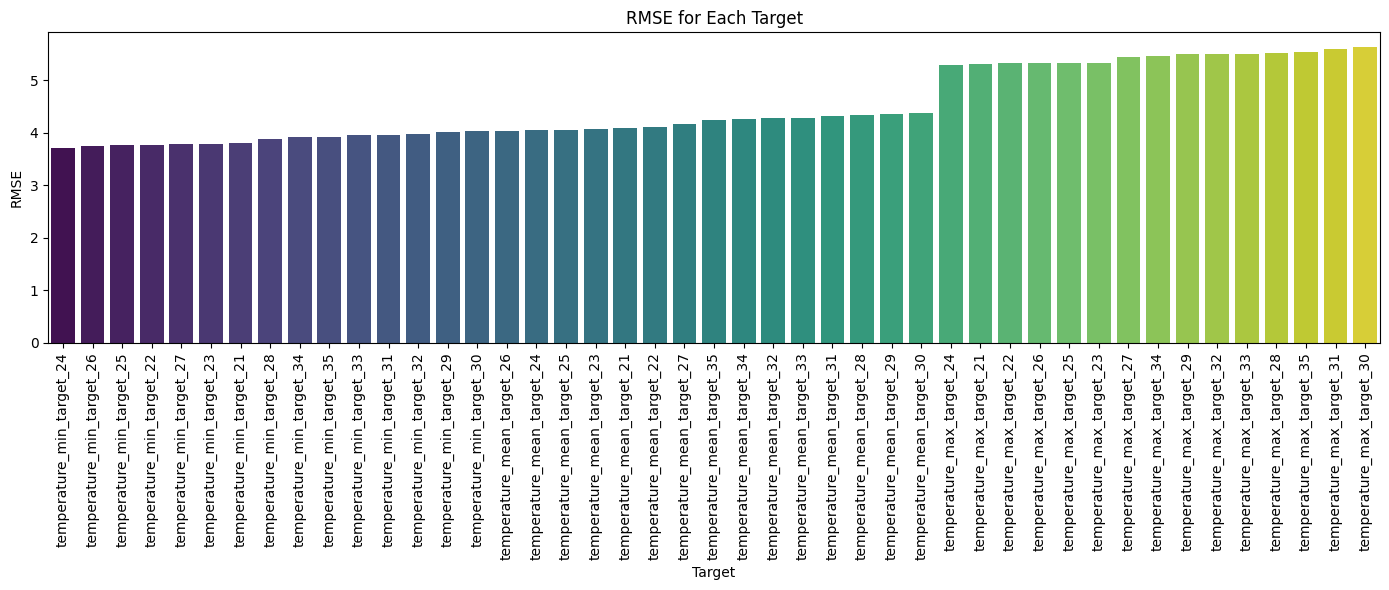

In [41]:
# Sort results by RMSE for better visualization
sorted_results = eval_df.sort_values(by='RMSE')

# 1. Bar Plot for RMSE Across All Targets
plt.figure(figsize=(14, 6))
sns.barplot(data=sorted_results, x='Target', y='RMSE', palette='viridis')
plt.xticks(rotation=90)
plt.title('RMSE for Each Target')
plt.xlabel('Target')
plt.ylabel('RMSE')
plt.tight_layout()

plt.savefig("../results/rmse_per_target.png")
plt.show()

C:\Users\Мария\AppData\Local\Temp\ipykernel_17836\1816234648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_results, x='Target', y='MAE', palette='coolwarm')


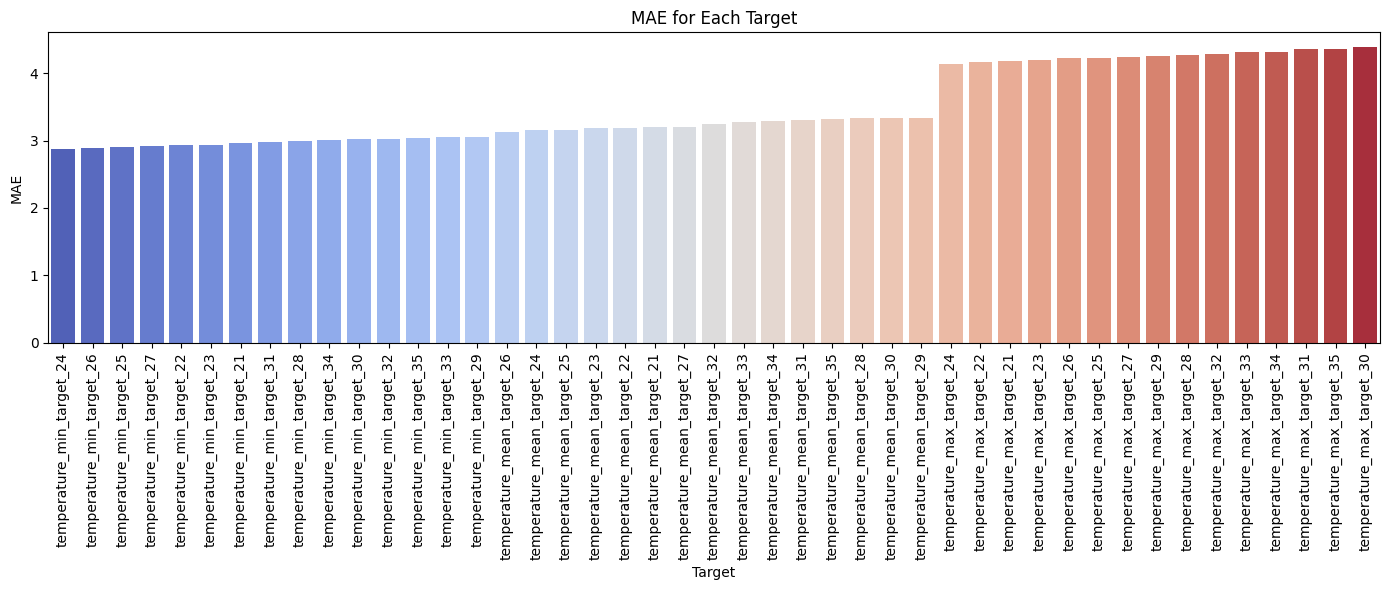

In [42]:
# Sort results by MAE for better visualization
sorted_results = eval_df.sort_values(by='MAE')

# 1. Bar Plot for MAE Across All Targets
plt.figure(figsize=(14, 6))
sns.barplot(data=sorted_results, x='Target', y='MAE', palette='coolwarm')
plt.xticks(rotation=90)
plt.title('MAE for Each Target')
plt.xlabel('Target')
plt.ylabel('MAE')
plt.tight_layout()
plt.savefig("../results/mae_per_target.png")
plt.show()

C:\Users\Мария\AppData\Local\Temp\ipykernel_17836\3494611762.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  station_errors = df.groupby(['Latitude', 'Longitude']).apply(lambda group: pd.Series({


Top 5 Best Stations (lowest RMSE):
          name  Latitude  Longitude      RMSE       MAE      Bias
12    Saalbach  47.38789   12.64844  3.292371  2.852524 -2.482625
2      Dellach  46.74189   13.08286  3.762608  3.075893 -2.843156
13     Jenbach  47.38878   11.75814  3.846354  3.039837 -2.348325
21  Bad Aussee  47.61050   13.75844  4.017170  3.292836 -2.884359
8      Brenner  47.00722   11.51083  4.023770  3.435224 -2.211746

Top 5 Worst Stations (highest RMSE):
                  name  Latitude  Longitude      RMSE       MAE      Bias
17           Fischbach  47.44417   15.64389  6.918051  5.901734 -5.717613
28        Schöngrabern  48.60333   16.06167  6.380899  4.707067 -3.381029
24           Amstetten  48.10889   14.89500  6.340599  4.468094 -3.999009
25  St.Pölten Landhaus  48.19972   15.63111  6.260824  4.484322 -3.685014
18             Bregenz  47.49917    9.74611  6.180068  4.701674 -4.109767

Best Station (lowest RMSE):
name         Saalbach
Latitude     47.38789
Longitude    1

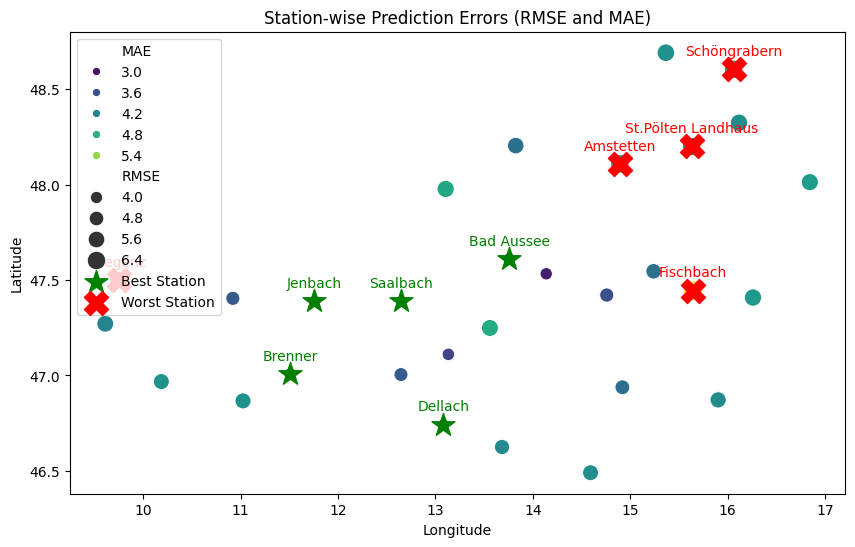

In [43]:
all_data = []
for idx, row in eval_df.iterrows():
    target = row['Target']
    # Convert string representations to actual lists
    predictions = ast.literal_eval(row['Predictions'])
    ground_truth = ast.literal_eval(row['Ground Truth'])
    latitudes = ast.literal_eval(row['Latitude'])
    longitudes = ast.literal_eval(row['Longitude'])
    
    for pred, gt, lat, lon in zip(predictions, ground_truth, latitudes, longitudes):
        all_data.append({
            'Target': target,
            'Prediction': pred,
            'GroundTruth': gt,
            'Latitude': lat,
            'Longitude': lon
        })

df = pd.DataFrame(all_data)

# --- Compute Error Metrics per Station ---
station_errors = df.groupby(['Latitude', 'Longitude']).apply(lambda group: pd.Series({
    'RMSE': np.sqrt(mean_squared_error(group['GroundTruth'], group['Prediction'])),
    'MAE': mean_absolute_error(group['GroundTruth'], group['Prediction']),
    'Bias': np.mean(group['Prediction'] - group['GroundTruth'])
})).reset_index()

# --- Merge with Station Metadata ---
# distributed_stations is assumed to have columns: 'lat', 'lon', and 'name'
station_errors = station_errors.merge(distributed_stations, left_on=['Latitude', 'Longitude'], 
                                        right_on=['lat', 'lon'], how='left')

# --- Identify Top 5 Best and Worst Stations ---
top_5_best = station_errors.nsmallest(5, 'RMSE')[['name', 'Latitude', 'Longitude', 'RMSE', 'MAE', 'Bias']]
top_5_worst = station_errors.nlargest(5, 'RMSE')[['name', 'Latitude', 'Longitude', 'RMSE', 'MAE', 'Bias']]

print("Top 5 Best Stations (lowest RMSE):")
print(top_5_best)
print("\nTop 5 Worst Stations (highest RMSE):")
print(top_5_worst)

# --- Identify Single Best and Worst Station ---
best_station = station_errors.loc[station_errors['RMSE'].idxmin()]
worst_station = station_errors.loc[station_errors['RMSE'].idxmax()]

print("\nBest Station (lowest RMSE):")
print(best_station[['name', 'Latitude', 'Longitude', 'RMSE', 'MAE', 'Bias']])
print("\nWorst Station (highest RMSE):")
print(worst_station[['name', 'Latitude', 'Longitude', 'RMSE', 'MAE', 'Bias']])

# --- Scatter Plot: Station Errors with Marked Top 5 Best & Worst ---
plt.figure(figsize=(10, 6))
# Plot all stations as background
scatter = sns.scatterplot(data=station_errors, x='Longitude', y='Latitude', 
                          size='RMSE', hue='MAE', palette='viridis', sizes=(50, 200), legend='brief')

# Mark top 5 best stations with green stars and annotate
for i, row in top_5_best.iterrows():
    plt.scatter(row['Longitude'], row['Latitude'], color='green', marker='*', s=300,
                label='Best Station' if i == top_5_best.index[0] else "")
    plt.annotate(row['name'], (row['Longitude'], row['Latitude']),
                 textcoords="offset points", xytext=(0,10), ha='center', color='green')
# Mark top 5 worst stations with red X markers and annotate
for i, row in top_5_worst.iterrows():
    plt.scatter(row['Longitude'], row['Latitude'], color='red', marker='X', s=300,
                label='Worst Station' if i == top_5_worst.index[0] else "")
    plt.annotate(row['name'], (row['Longitude'], row['Latitude']),
                 textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Station-wise Prediction Errors (RMSE and MAE)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.savefig("../results/station_predictions.png")
plt.show()

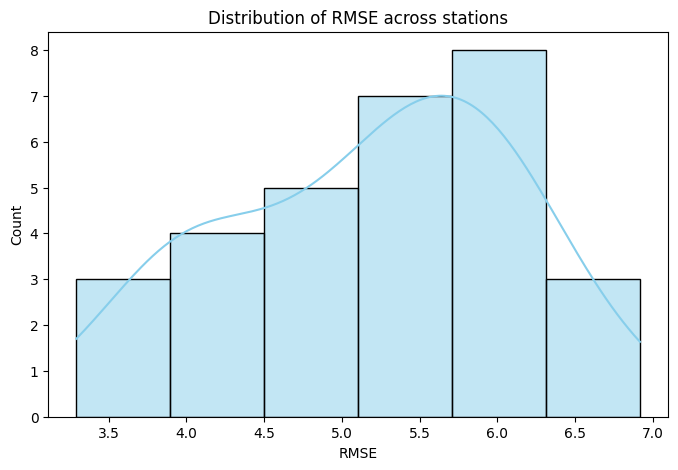

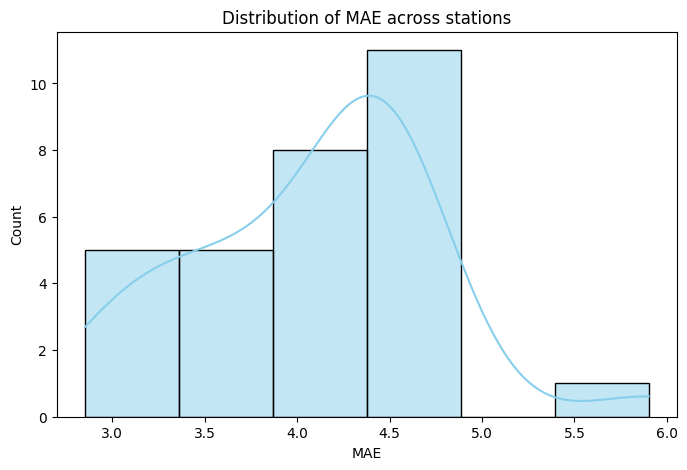

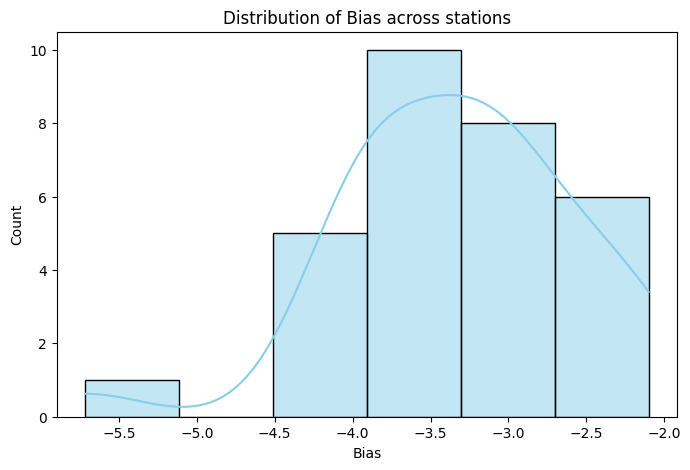

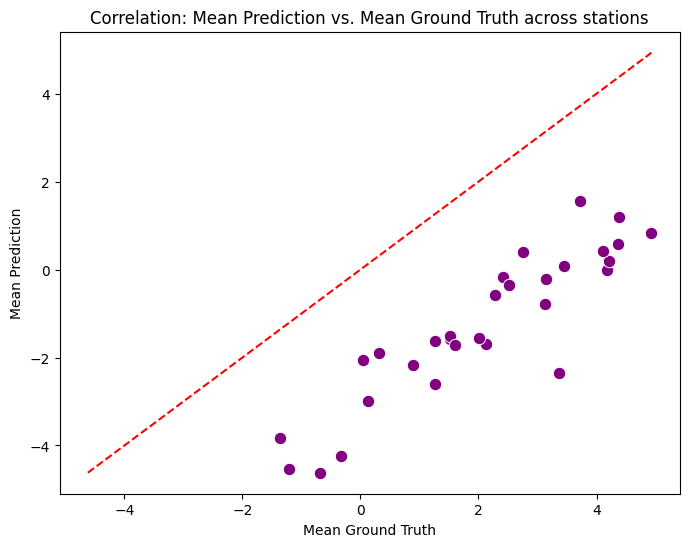

In [44]:
# Distribution Plots for RMSE, MAE, and Bias
for metric in ['RMSE', 'MAE', 'Bias']:
    plt.figure(figsize=(8, 5))
    sns.histplot(station_errors[metric], kde=True, color='skyblue')
    plt.title(f'Distribution of {metric} across stations')
    plt.xlabel(metric)
    plt.ylabel('Count')
    plt.savefig(f"../results/dist_{metric}.png")
    plt.show()

# Correlation Plot: Average Prediction vs. Average Ground Truth Across All Stations
station_means = df.groupby(['Latitude', 'Longitude']).agg({
    'Prediction': 'mean',
    'GroundTruth': 'mean'
}).reset_index()
# Merge with station metadata for names, if needed
station_means = station_means.merge(distributed_stations, left_on=['Latitude', 'Longitude'],
                                    right_on=['lat', 'lon'], how='left')
plt.figure(figsize=(8,6))
sns.scatterplot(data=station_means, x='GroundTruth', y='Prediction', s=80, color='purple')
min_val = min(station_means['GroundTruth'].min(), station_means['Prediction'].min())
max_val = max(station_means['GroundTruth'].max(), station_means['Prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title('Correlation: Mean Prediction vs. Mean Ground Truth across stations')
plt.xlabel('Mean Ground Truth')
plt.ylabel('Mean Prediction')
plt.savefig(f"../results/corr_plot.png")
plt.show()

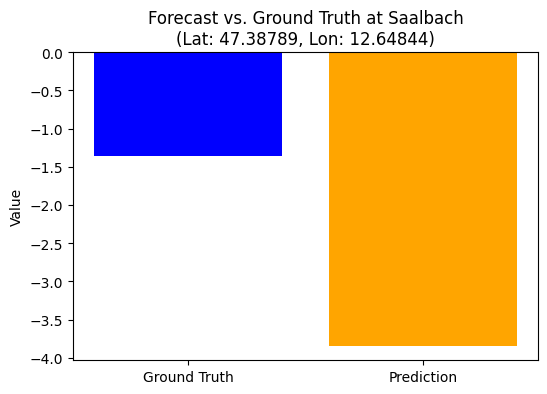

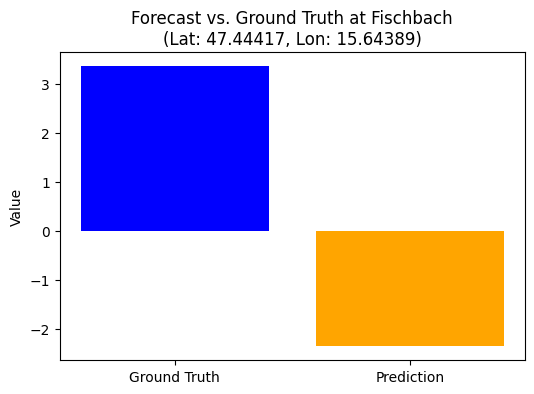

In [46]:
# Single Forecast vs. Ground Truth for Selected Stations (Best and Worst)
for station in [best_station, worst_station]:
    # Filter data for the selected station
    station_data = df[(df['Latitude'] == station['Latitude']) & (df['Longitude'] == station['Longitude'])]
    # If multiple rows exist (different targets), take the mean (or plot them separately)
    mean_pred = station_data['Prediction'].mean()
    mean_gt = station_data['GroundTruth'].mean()
    plt.figure(figsize=(6, 4))
    plt.bar(['Ground Truth', 'Prediction'], [mean_gt, mean_pred], color=['blue', 'orange'])
    plt.title(f"Forecast vs. Ground Truth at {station['name']}\n(Lat: {station['Latitude']}, Lon: {station['Longitude']})")
    plt.ylabel("Value")
    plt.savefig(f"../results/forecast_ground_{station['name']}.png")
    plt.show()